
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [3]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('medical-charges.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Ідеї для вирішення задачі:
- Булеві параметри перевести у 1 і 0.
- Для категоріальних параметрів із кількох значень: розділити на підтаблиці для кожного значення і порівняти для них статистику по таргету. В залежності від цього підібрати числові значення для категорій (наприклад 1, 2, 3). Замінити категоріальні значення на ці числові.
- Порахувати кореляції з таргетом для числових параметрів.
- Вибрати параметри з найбільшими кореляціями.
- Вручну підібрати коефіцієнти для функції, типу: t = ax + by + .. + c, де t - значення таргета, x, y... - значення параметрів, a, b... - коефіцієнти для них, c - константа.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [5]:
def build_hist(x_col, color_col, marginal_type=None):
  fig = px.histogram(df,
                    x=x_col,
                    marginal=marginal_type,
                    color = color_col,
                    title=f'Distribution of {x_col} by {color_col}')
  fig.update_layout(bargap=0.1)
  fig.show()

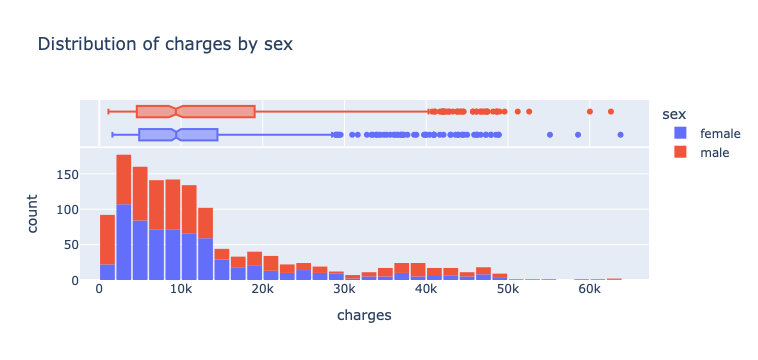

In [6]:
build_hist('charges', 'sex', 'box')

**Спостереження**
- Для обох статей розподіл виглядає право-скошеним, тобто більша частина значень знаходиться зліва.
- Для обох статей доволі багато викидів.
- Для жінок розподіл більш щільний.
- Медіана трохи вища для жінок.
- Без урахування викидів, максимальне значення для чоловіків більше, ніж для жінок, а мінімальне - менше.

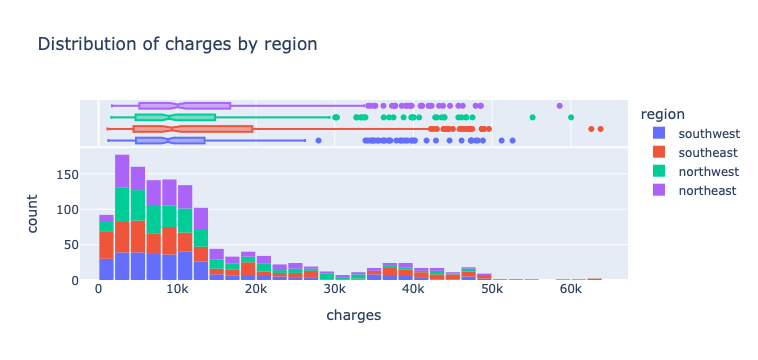

In [7]:
build_hist('charges', 'region', 'box')

**Спостереження**
- Для усіх регіонів розподіл виглядає правоскошеним.
- Всі регіони мають викиди по правій стороні.
- SW регіон має найбільш широкий розподіл.
- NW регіон має найвищу медіану.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

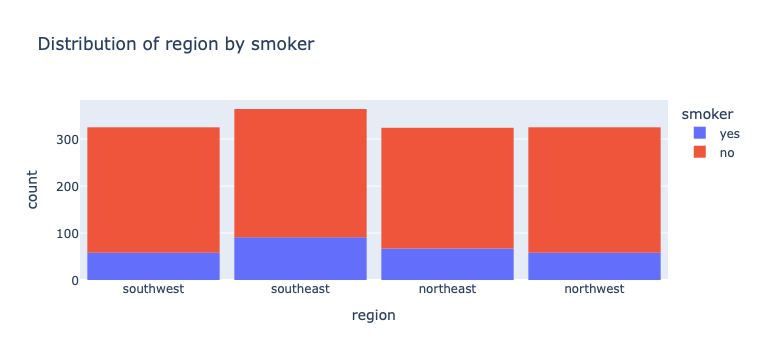

In [8]:
build_hist('region', 'smoker')

**Спостереження**
- В кожному регіоні курців менше, ніж некурців.
- Розподіл по регіонам приблизно рівномірний, трохи більше даних для регіону SE.
- В регіоні SE найбільший відсоток курців.

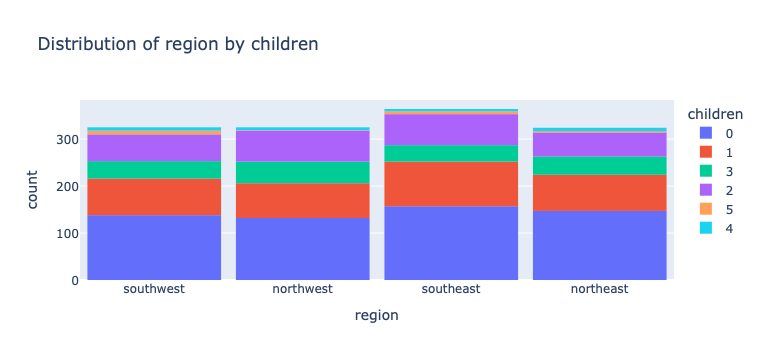

In [9]:
build_hist('region', 'children')

**Спостереження**
- Найбільша кількість людей не мають дітей у кожному регіоні.
- Дуже мало людей мають більше 3 дітей.
- Розподіл по дітям загалом однаковий у регіонах.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

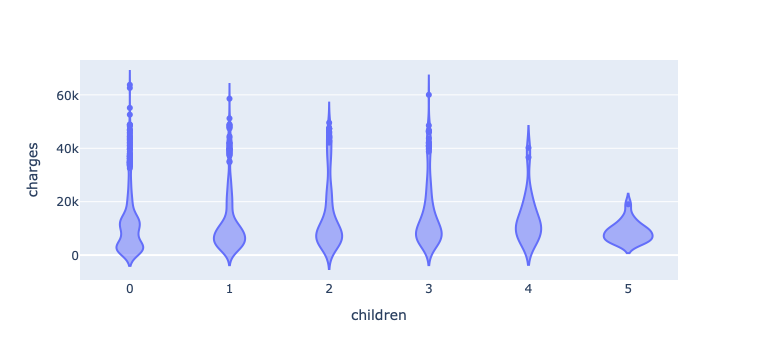

In [10]:
px.violin(df, x='children', y='charges')

**Спостереження**
- Для 0 дітей є два значення розміру платежа, де сконцетровано найбільше записів: приблизно 2'500 і 11'000.
- Для всіх інших кількостей дітей це одне значення концентрації.
- Для 5 дітей найбільш вузький розподіл таргета, але і записів там мало.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [11]:
non_smoker_df = df[df.smoker == 'no']

In [12]:
def estimate_charges(age, w, b):
    return w * age + b

In [13]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

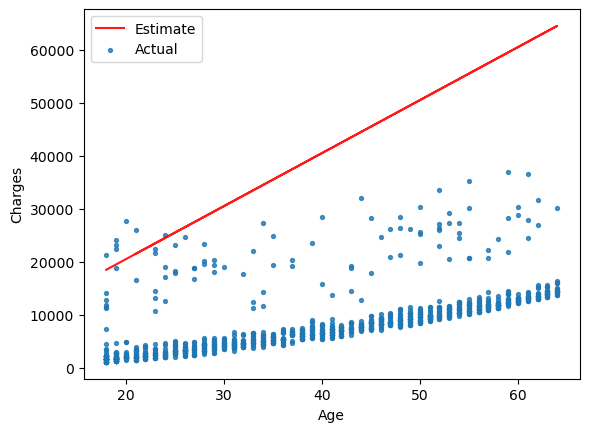

In [14]:
try_parameters(non_smoker_df, 1000, 500)

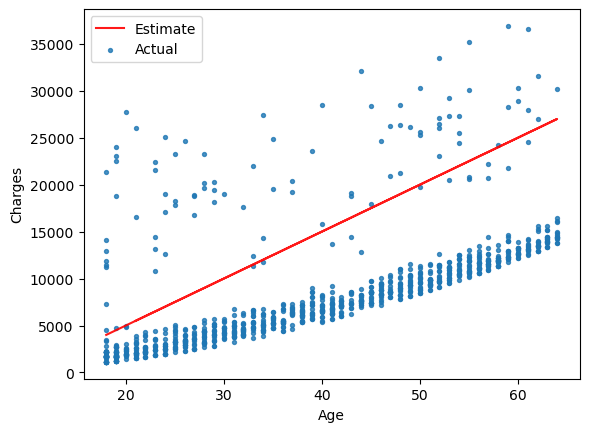

In [15]:
try_parameters(non_smoker_df, 500, -5000)

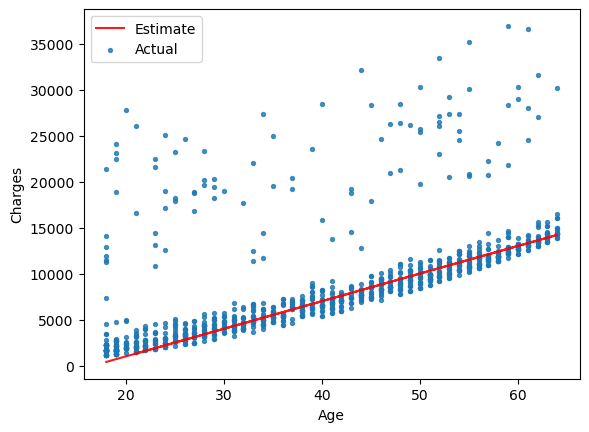

In [16]:
try_parameters(non_smoker_df, 300, -5000)

**Спостереження**
- Параметр b виявився від'ємним.
- Вдалось доволі добре влучити в зону основної концентрації точок, але решта точок може виявити неточності у моїх параметрах.
- Загалом видно чітку залежність таргету від віку.
- Відносно мала кількість некурців має значення таргету поза зоною основної концентрації.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [17]:
def calculate_rmse(predicted, actual):
  rmse = np.sqrt(np.mean(np.square(predicted - actual)))
  return rmse

In [18]:
def get_rmse(df, column, w, b):
  actual = df['charges']
  predicted = w * df[column] + b
  rmse = calculate_rmse(predicted, actual)
  return rmse

In [19]:
def print_rmse(df, column, w, b):
  rmse = get_rmse(df, column, w, b)
  print(f'RMSE for w={w} and b={b} is {rmse}')

In [20]:
# RMSE для значень, отриманих вище
print_rmse(non_smoker_df, 'age', 1000, 500)
print_rmse(non_smoker_df, 'age', 500, -5000)
print_rmse(non_smoker_df, 'age', 300, -5000)

RMSE for w=1000 and b=500 is 33426.09046777991
RMSE for w=500 and b=-5000 is 8464.116108792541
RMSE for w=300 and b=-5000 is 4956.973980899423


In [21]:
# Спроба знайти найкращі значення для w i b через RMSE
# Cпочатку підбираємо w
print_rmse(non_smoker_df, 'age', 200, -5000)
print_rmse(non_smoker_df, 'age', 400, -5000)
print_rmse(non_smoker_df, 'age', 350, -5000)
print_rmse(non_smoker_df, 'age', 325, -5000)
print_rmse(non_smoker_df, 'age', 375, -5000)
print_rmse(non_smoker_df, 'age', 340, -5000)
print_rmse(non_smoker_df, 'age', 335, -5000)
print_rmse(non_smoker_df, 'age', 330, -5000)
print_rmse(non_smoker_df, 'age', 333, -5000)
print_rmse(non_smoker_df, 'age', 334, -5000)
print_rmse(non_smoker_df, 'age', 332, -5000)

RMSE for w=200 and b=-5000 is 7315.571261841366
RMSE for w=400 and b=-5000 is 5532.88507495513
RMSE for w=350 and b=-5000 is 4818.589201659388
RMSE for w=325 and b=-5000 is 4775.127841945322
RMSE for w=375 and b=-5000 is 5081.580365358308
RMSE for w=340 and b=-5000 is 4773.847019337683
RMSE for w=335 and b=-5000 is 4765.104843185915
RMSE for w=330 and b=-5000 is 4765.532605510242
RMSE for w=333 and b=-5000 is 4764.17450773912
RMSE for w=334 and b=-5000 is 4764.456117173326
RMSE for w=332 and b=-5000 is 4764.2600799827


In [22]:
print("The best w = 333")

The best w = 333


In [23]:
# Тепер підбираємо b
print_rmse(non_smoker_df, 'age', 333, -5000)
print_rmse(non_smoker_df, 'age', 333, -4000)
print_rmse(non_smoker_df, 'age', 333, -6000)
print_rmse(non_smoker_df, 'age', 333, -4500)
print_rmse(non_smoker_df, 'age', 333, -4250)
print_rmse(non_smoker_df, 'age', 333, -4750)
print_rmse(non_smoker_df, 'age', 333, -4875)
print_rmse(non_smoker_df, 'age', 333, -4625)
print_rmse(non_smoker_df, 'age', 333, -4550)
print_rmse(non_smoker_df, 'age', 333, -4700)
print_rmse(non_smoker_df, 'age', 333, -4750)
print_rmse(non_smoker_df, 'age', 333, -4675)
print_rmse(non_smoker_df, 'age', 333, -4683)
print_rmse(non_smoker_df, 'age', 333, -4690)
print_rmse(non_smoker_df, 'age', 333, -4687)
print_rmse(non_smoker_df, 'age', 333, -4680)
print_rmse(non_smoker_df, 'age', 333, -4677)
print_rmse(non_smoker_df, 'age', 333, -4682)
print_rmse(non_smoker_df, 'age', 333, -4681)

RMSE for w=333 and b=-5000 is 4764.17450773912
RMSE for w=333 and b=-4000 is 4802.026393391101
RMSE for w=333 and b=-6000 is 4933.078146305593
RMSE for w=333 and b=-4500 is 4756.932636847826
RMSE for w=333 and b=-4250 is 4772.989922173142
RMSE for w=333 and b=-4750 is 4753.986056547668
RMSE for w=333 and b=-4875 is 4757.441127646296
RMSE for w=333 and b=-4625 is 4753.81644246797
RMSE for w=333 and b=-4550 is 4755.292122927502
RMSE for w=333 and b=-4700 is 4753.523783782019
RMSE for w=333 and b=-4750 is 4753.986056547668
RMSE for w=333 and b=-4675 is 4753.489858151289
RMSE for w=333 and b=-4683 is 4753.486409111326
RMSE for w=333 and b=-4690 is 4753.494435718596
RMSE for w=333 and b=-4687 is 4753.489733515321
RMSE for w=333 and b=-4680 is 4753.486124712472
RMSE for w=333 and b=-4677 is 4753.487733660611
RMSE for w=333 and b=-4682 is 4753.486103939795
RMSE for w=333 and b=-4681 is 4753.4860091401715


In [24]:
print("The best b = -4681")

The best b = -4681


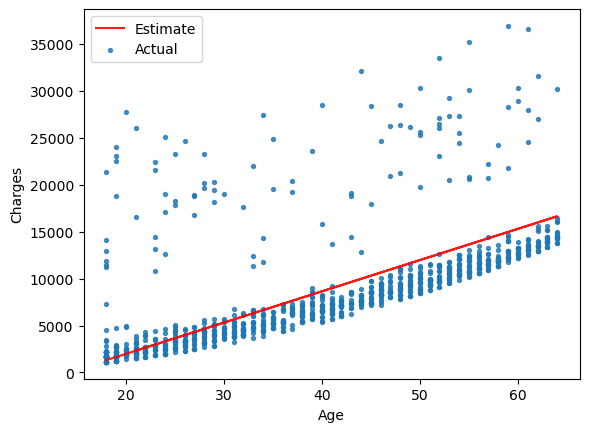

In [25]:
# Перевіримо отримані параметри на графіку
try_parameters(non_smoker_df, 333, -4681)

- Найнижче значення втрат - це 4753.4860 при w=333 і b=-4681.
- Знаходив ці значення за такою стратегією:
  - Взяти значення w i b, що дали найкраще значення RMSE в попередньому завданні.
  - Спочатку знайти значення w, без змін b:
    - знайти такі 2 значення w, щоб поточне найкраще значення w було між ними і щоб RMSE в цих точках було більшим за поточне (тобто створити такий відрізок w_min < w < w_max, що найменше значення RMSE буде всередині нього).
    - перевірити 2 значення ближчі до поточного (звузити відрізок).
    - коли одне зі значень дає кращу величину RMSE, воно стає новим поточним значенням w, а найближчі перевірені до нього - межами відрізку.
    - повторюємо поки не зупинимось на такому w, для якого RMSE(w-1) > RMSE(w) < RMSE(w+1)
  - Беремо значення w, яке ми отримали на попередньому кроці, і так само знаходимо значення b.